In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/CBEM_pytorch
    # !git pull
    
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import seaborn as sns
sys.path.append(str(Path.cwd().parent))
from utils._raised_cosine_basis import makeRaisedCosBasis
# from utils.load_matlab import load_mat_v73, flatten_cell
from scipy.ndimage import gaussian_filter1d
import utils
from utils import *
# from utils.CBEM import CBEM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

plt.rcParams['figure.dpi'] = 100 #

PyTorch: 2.10.0+cu128
CUDA available: False


## Load Data to evaluate model

In [2]:
project_root = Path.cwd().parent
models_dir = "saved_models"
data_dir = project_root / "Data"

In [3]:
file_path = data_dir / "PinkNoise_WholeCell_Light_beta_0_OFF_transient_medium_RF_032025Bc3_rs.npz"
data_test   = np.load(file_path, allow_pickle=True)
stim_rs        = data_test["stim"]
spktimes_rs      = data_test['spk_times']
spk_t_test       = data_test['spk_train']
V_test  = data_test['raw_traces'] # shape (N_test,  T_v)

In [4]:
dt = 1e-4
# stimulus frames are at 60 Hz
# CBEM runs at 0.1 ms bins, so we upsample stimulus and re-bin spikes from spike times
dt_stim = 1 / 60.0
trial_dur_s = stim_rs.shape[1] * dt_stim

# Trim 0.5 s on each side to avoid edge effects
presamples = int(round(0.5 / dt))
postsamples = int(round(0.5 / dt))

T_cell_full = int(round(trial_dur_s / dt))
bin_edges_s = np.arange(T_cell_full + 1) * dt

stimulus_test, spk_test = preprocess_split(stim_rs, spktimes_rs, 
                                           presamples=presamples, postsamples=postsamples, 
                                           n_trials=len(spktimes_rs), 
                                        T_cell_full=T_cell_full, dt_stim=dt_stim, dt=dt, bin_edges_s=bin_edges_s)


spk_idx_test = [
    torch.as_tensor(np.where(spk_test[b] > 0)[0], device=device, dtype=torch.long)
    for b in range(spk_test.shape[0])
]


psth_hz = spk_test.mean(axis=0) / dt   # [T] in Hz
psth_hz_smooth = gaussian_filter1d(psth_hz, sigma=int(0.02 / dt))  # 20 ms smoothing



In [5]:
nLinearRFs = 10 #;     %number of stimulus basis functions
numShortSHFilts = 5#; %each is 0.4ms long - used for refractory period
nSHfilters = 7+numShortSHFilts#;%7+

nInh = 1#;
nExc = 1#

RFstart = 2e-3 #;%0?
RFend   = 150e-3#;%150e-3 or 180e-3;
b = 0.02
t, B_orth, B_raw = makeRaisedCosBasis(nLinearRFs, dt, [RFstart, RFend], b, zflag=0)
B_orth.shape

(2478, 10)

In [6]:
## LOAD trained model
ckpt_full = torch.load(f"{models_dir}/fuck_yeah.pt", map_location=device)

trained = CBEM_trials(binsize_s=ckpt_full["binsize_s"]).to(device)

# IMPORTANT: initialize lazy parameter before loading
# (or call trained once on dummy input with correct D)
D = ckpt_full["model_state_dict"]["B_cond"].shape[0]
trained._maybe_init_B_cond_from_D(D, device=device, dtype=torch.float32)
# t, B_orth, B_raw = makeRaisedCosBasis(10, dt, [2e-3, 150-3], 0.02, zflag=0) #should ne part of model state?

trained.load_state_dict(ckpt_full["model_state_dict"])
trained.eval()

steps_hist = ckpt_full.get("steps_hist", None)
loss_hist  = ckpt_full.get("loss_hist", None)

##Load Linear model
ckpt_linear = torch.load(f"{models_dir}/lin_model.pt", map_location=device)

cbem_lin = CBEM_linear(binsize_s=ckpt_linear["binsize_s"]).to(device)

# IMPORTANT: initialize lazy parameter before loading
# (or call trained once on dummy input with correct D)
D = ckpt_linear["model_state_dict"]["B_cond"].shape[0]
cbem_lin._maybe_init_B_cond_from_D(D, device=device, dtype=torch.float32)
# t, B_orth, B_raw = makeRaisedCosBasis(10, dt, [2e-3, 150-3], 0.02, zflag=0) #should ne part of model state?

cbem_lin.load_state_dict(ckpt_linear["model_state_dict"])
cbem_lin.eval()


CBEM_linear()

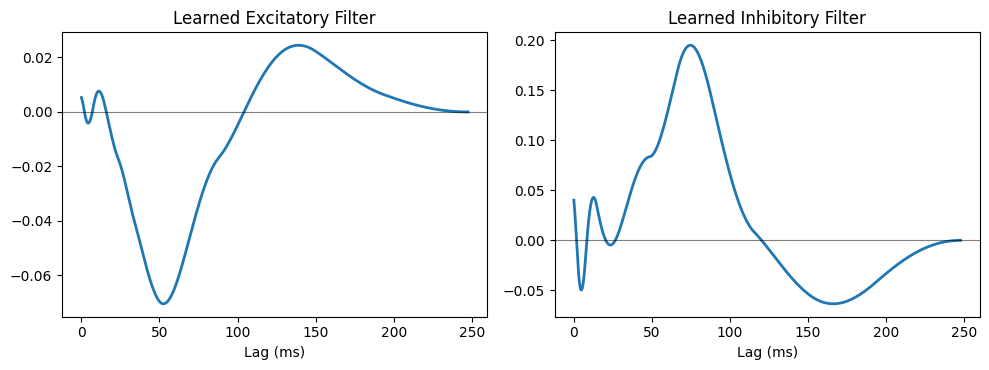

In [7]:
# Learned conductance filters in time domain
B = trained.B_cond.detach().cpu()   # [D, 2]
np.savez("B_trained", B)
W_orth = B[:-1, :]                  # drop bias row

B_orth_t = torch.as_tensor(B_orth, dtype=W_orth.dtype)
filters = B_orth_t @ W_orth            # [L, 2]

t_ms = np.arange(filters.shape[0]) * dt * 1e3

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(t_ms, filters[:, 0].numpy(), lw=2.0)
axes[0].set_title('Learned Excitatory Filter')
axes[0].set_xlabel('Lag (ms)')

axes[1].plot(t_ms, filters[:, 1].numpy(), lw=2.0)
axes[1].set_title('Learned Inhibitory Filter')
axes[1].set_xlabel('Lag (ms)')

for ax in axes:
    ax.axhline(0.0, color='k', lw=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

## Evaluate trained model

In [16]:
##Design Matrix test stim
stim_test_t = torch.as_tensor(stimulus_test, dtype=torch.float32, device=device)

# stimulus_t: [B, T]
# basis_t: [L, P]
X_test_tr = [
    convolveStimulusWithBasis_torch(stim_test_t[b], B_orth_t, add_ones=True)  # -> [T, P+1]
    for b in range(stimulus_test.shape[0])
]
X_test = torch.stack(X_test_tr, dim=0)  # [B,T,D]
print('X_full:', X_test.shape)


def simulate_model(trained, X_test):
    ## FULL MODEL
    with torch.no_grad():
        rate_test, aux = trained(X_test)  # [B,T]
        
    B = X_test.shape[0]
    T0 = 500
    Y_init = torch.zeros(B, T0, device=X_test.device, dtype=X_test.dtype)  # [B,T0]
    sps_t = trained.simulateSpikeTrains_trials(X_test, Y_init, seed=0).detach().cpu().numpy()
    # sps: [B,T] in {0,1}
    B, T = sps_t.shape
    

    return rate_test, aux, sps_t

rate_test, aux, sps_t = simulate_model(trained, X_test)

# Build spike times (ms) per trial for eventplot
spkTimes_ms_by_trial = [
        np.where(sps_t[b, :] > 0)[0] * dt * 1e3
        for b in range(rate_test.shape[0])]
## LIN MODEL STATS
with torch.no_grad():
    psth_lin, aux_lin = cbem_lin(X_test)  # [B,T]
    
    


X_full: torch.Size([6, 100000, 11])


In [17]:
rate_hat = rate_test.detach().cpu()
rate_lin = psth_lin.detach().cpu()

rate_hat = gaussian_filter1d(rate_hat[0], sigma=max(1, int(0.02 / dt)))  # 20 ms
rate_lin = gaussian_filter1d(rate_lin[0], sigma=max(1, int(0.02 / dt)))  # 20 ms

In [18]:
gs = aux['gs']
Vm = aux['V']
gs.shape, Vm.shape

(torch.Size([6, 100000, 2]), torch.Size([6, 100000]))

In [19]:
dt_s = 1e-4
trial = 1
L = 100000

Vm_np = Vm.detach().cpu().numpy() if hasattr(Vm, "detach") else Vm
t_ms = np.arange(L) * dt_s * 1e3

spk_idx = np.where(sps_t[trial, :L] > 0)[0]
spk_ms  = spk_idx * dt_s * 1e3

Vm0 = Vm_np[trial, :L]
Vm_at_spk = Vm0[spk_idx]



# make each spike a short tick starting at Vm(t_spike)


## Conductance -> current -> ATP

$g(t) \to I_{ion}(t) \to Q_{ion} \to N_{ions} \to ATP$
- Synpatic currents

    $I_{exc}(t) = g_{exc}(t) * (E_{exc} - V_m(t))$ 

    and 

    $I_{inh}(t) = g_{inh}(t) * (E_{inh} - V_m(t))$

    Using $E_{exc} = 0 mV$ and $E_{inh} = -80 mv$
- Leak current

    $I_{leak}(t) = g_{leak} * (E_{leak} - V_m(t))$
- Spiking currents


In [20]:
def compute_I_syn(gs, Vm, dt=1e-4, E_exc=0.0, E_inh=-80.0):
    """
    gs: [B, T, 2]   where gs[..., 0] = g_exc, gs[..., 1] = g_inh
    Vm: [B, T]

    Returns
    -------
    I_syn: [B, T, 2]
        I_syn[..., 0] = I_exc = g_exc * (E_exc - Vm)
        I_syn[..., 1] = I_inh = g_inh * (E_inh - Vm)
    """
    E = torch.tensor([E_exc, E_inh], dtype=gs.dtype, device=gs.device)   # [2]
    I_syn = gs * (E[None, None, :] - Vm[..., None])                      # [B,T,2]
    return I_syn

In [21]:
I_syn = compute_I_syn(gs, Vm)
Q_syn = (I_syn * dt * 1e-12).sum(dim=1)   # [B, 2], in coulombs
Q_exc = Q_syn[:,0]
e = 1.602e-19
N_ions_exc = Q_exc / e
f_Na = 0.8

N_ions_exc = Q_exc / e
N_Na_exc = f_Na * N_ions_exc
ATP_exc = N_Na_exc / 3

spike_counts = torch.tensor(
    [len(tr) for tr in spkTimes_ms_by_trial],
    dtype=ATP_exc.dtype,
    device=ATP_exc.device
)

ATP_exc_per_spike = torch.full_like(ATP_exc, float("nan"))
mask = spike_counts > 0
ATP_exc_per_spike[mask] = ATP_exc[mask] / spike_counts[mask]

In [22]:
print("ATP_exc:", ATP_exc[:5])
print("spike_counts:", spike_counts[:5])
print("ATP_exc_per_spike:", ATP_exc_per_spike[:5])

print("mean ATP/trial:", ATP_exc.mean().item())
print("mean spikes/trial:", spike_counts.float().mean().item())
print("mean ATP/spike:", torch.nanmean(ATP_exc_per_spike).item())

ATP_exc: tensor([9.1591e+09, 9.1591e+09, 9.1591e+09, 9.1591e+09, 9.1591e+09])
spike_counts: tensor([74., 85., 70., 57., 64.])
ATP_exc_per_spike: tensor([1.2377e+08, 1.0775e+08, 1.3084e+08, 1.6069e+08, 1.4311e+08])
mean ATP/trial: 9159128064.0
mean spikes/trial: 70.33333587646484
mean ATP/spike: 132229848.0


In [32]:
import torch
import numpy as np

def compute_energy_metrics(gs, Vm, sps_t, dt=1e-4, f_Na=0.8):
    """
    gs: [B,T,2] torch tensor
    Vm: [B,T] torch tensor
    sps_t: [B,T] numpy array or torch tensor of 0/1 spikes

    Returns dict of per-trial and summary metrics.
    """
    if not torch.is_tensor(sps_t):
        sps = torch.as_tensor(sps_t, dtype=gs.dtype, device=gs.device)
    else:
        sps = sps_t.to(gs.device, gs.dtype)

    I_syn = compute_I_syn(gs, Vm, dt=dt)                # [B,T,2], pA
    I_exc_in = torch.clamp(I_syn[..., 0], min=0)        # [B,T], pA
    Q_exc = (I_exc_in * dt * 1e-12).sum(dim=1)          # [B], C

    e = 1.602e-19
    ATP_exc = f_Na * (Q_exc / e) / 3                    # [B]

    spike_counts = sps.sum(dim=1)                       # [B]

    ATP_exc_per_spike = torch.full_like(ATP_exc, float("nan"))
    mask = spike_counts > 0
    ATP_exc_per_spike[mask] = ATP_exc[mask] / spike_counts[mask]

    rate_hz_trial = spike_counts / (sps.shape[1] * dt)

    out = {
        "ATP_exc": ATP_exc,
        "ATP_exc_per_spike": ATP_exc_per_spike,
        "spike_counts": spike_counts,
        "rate_hz_trial": rate_hz_trial,
        "Q_exc": Q_exc,
        "Vm_mean_trial": Vm.mean(dim=1),
        "Vm_std_trial": Vm.std(dim=1),
        "g_exc_mean_trial": gs[..., 0].mean(dim=1),
        "g_inh_mean_trial": gs[..., 1].mean(dim=1),
        "summary": {
            "mean_ATP_exc": ATP_exc.mean().item(),
            "mean_ATP_exc_per_spike": torch.nanmean(ATP_exc_per_spike).item(),
            "mean_spike_count": spike_counts.float().mean().item(),
            "mean_rate_hz": rate_hz_trial.mean().item(),
            "mean_Vm": Vm.mean().item(),
            "std_Vm": Vm.std().item(),
            "mean_g_exc": gs[..., 0].mean().item(),
            "mean_g_inh": gs[..., 1].mean().item(),
        }
    }
    return out

In [37]:
g_l_span = torch.linspace(100, 300, 10, device=trained.g_l.device, dtype=trained.g_l.dtype)

results = []
g_l_orig = trained.g_l.clone()

for g_l_val in g_l_span:
    with torch.no_grad():
        trained.g_l.fill_(g_l_val)

        rate_test, aux = trained(X_test)
        B = X_test.shape[0]
        T0 = 500
        Y_init = torch.zeros(B, T0, device=X_test.device, dtype=X_test.dtype)
        sps_t = trained.simulateSpikeTrains_trials(X_test, Y_init, seed=0).detach().cpu().numpy()

        gs = aux["gs"]
        Vm = aux["V"]

        metrics = compute_energy_metrics(gs, Vm, sps_t, dt=dt, f_Na=0.8)

        summary = metrics["summary"].copy()
        summary["g_l"] = float(g_l_val.item())
        results.append(summary)

with torch.no_grad():
    trained.g_l.copy_(g_l_orig)

In [38]:
g_l_vals = np.array([r["g_l"] for r in results])
mean_rate = np.array([r["mean_rate_hz"] for r in results])
mean_ATP = np.array([r["mean_ATP_exc"] for r in results])
mean_ATP_per_spike = np.array([r["mean_ATP_exc_per_spike"] for r in results])
mean_Vm = np.array([r["mean_Vm"] for r in results])
mean_g_exc = np.array([r["mean_g_exc"] for r in results])


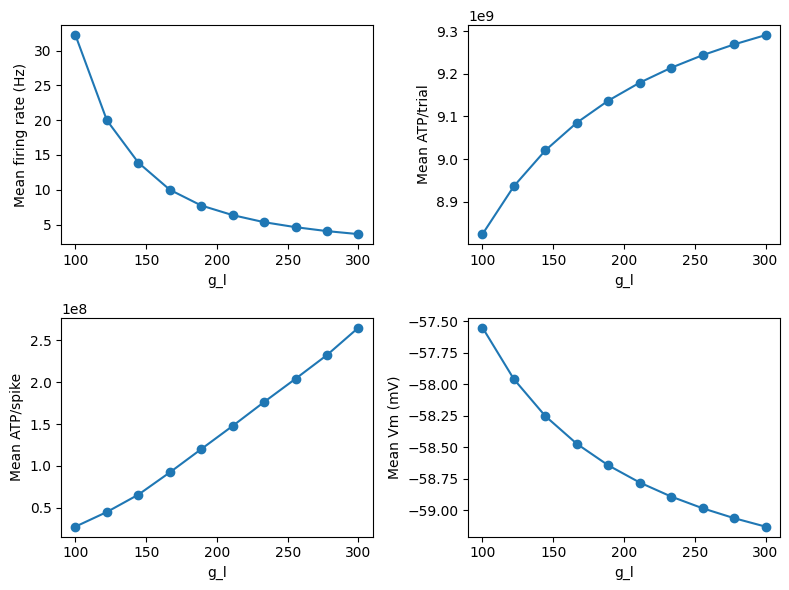

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

axes[0,0].plot(g_l_vals, mean_rate, '-o')
axes[0,0].set_xlabel("g_l")
axes[0,0].set_ylabel("Mean firing rate (Hz)")

axes[0,1].plot(g_l_vals, mean_ATP, '-o')
axes[0,1].set_xlabel("g_l")
axes[0,1].set_ylabel("Mean ATP/trial")

axes[1,0].plot(g_l_vals, mean_ATP_per_spike, '-o')
axes[1,0].set_xlabel("g_l")
axes[1,0].set_ylabel("Mean ATP/spike")

axes[1,1].plot(g_l_vals, mean_Vm, '-o')
axes[1,1].set_xlabel("g_l")
axes[1,1].set_ylabel("Mean Vm (mV)")

plt.tight_layout()
plt.show()

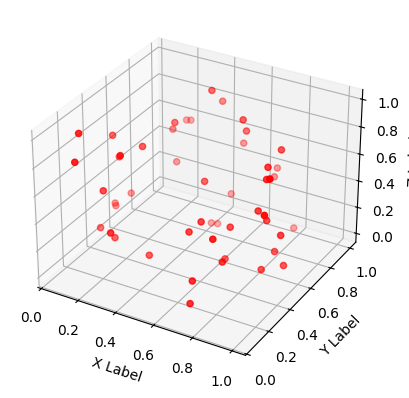

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Import the mplot3d toolkit
from mpl_toolkits.mplot3d import Axes3D

# Create data
# For a real application, you would use your own data
x = np.random.rand(50)
y = np.random.rand(50)
z = np.random.rand(50)

# Create a figure and a 3D axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d') # or use ax = plt.axes(projection='3d')

# Plot the data
ax.scatter(x, y, z, c='r', marker='o') # 'c' for color, 'marker' for point style

# Set labels for axes
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

# Display the plot
plt.show()


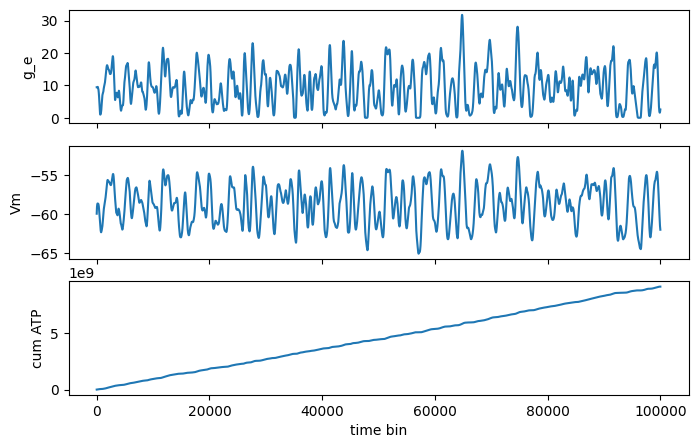

In [25]:
I_exc_in = I_syn[:,:,0]
trial = 0
cum_ATP = torch.cumsum(I_exc_in[trial] * dt * 1e-12 / e * f_Na / 3, dim=0)

fig, axes = plt.subplots(3,1, figsize=(8,5), sharex=True)
axes[0].plot(gs[trial,:,0].cpu())
axes[0].set_ylabel("g_e")
axes[1].plot(Vm[trial].cpu())
axes[1].set_ylabel("Vm")
axes[2].plot(cum_ATP.cpu())
axes[2].set_ylabel("cum ATP")
axes[2].set_xlabel("time bin")
plt.show()

In [26]:
trial_duration_s = gs.shape[1] * dt

ATP_rate = ATP_exc / trial_duration_s
ATP_per_spike = ATP_exc_per_spike

ATP_rate, ATP_per_spike

(tensor([9.1591e+08, 9.1591e+08, 9.1591e+08, 9.1591e+08, 9.1591e+08, 9.1591e+08]),
 tensor([1.2377e+08, 1.0775e+08, 1.3084e+08, 1.6069e+08, 1.4311e+08, 1.2721e+08]))

### Charge transfer
$$Q_{exc} = \int I_{exc}(t) dt$$
$$Q_{inh} = \int I_{inh}(t) dt$$



## ATP
$$ATP_{syn} \approx \frac{f_{Na}Q_e}{3e}$$
$$ATP_{spikes} \approx c_{spk}N_{spks}$$
$$ATP_{leak}  \approx  $$
$$ ATP_{total} = ATP_{syn} + ATP_{spikes} + ATP_{leak}$$

$$